## Ordinary differential equations

Now we're going to turn to a huge and important topic in numerical methods: numerically integrating (i.e., numerically approximating the solutions of) _ordinary differential equations (ODEs)_. 

Why are ODEs important? Board lecture.

In [26]:
# Function to return RHS of particle trajectory ODE, 
# given current state u and parameters p

# p is expected to be a tuple (rhog, a, mu, g, mp)
function drop_rhs(u, p)
    rhog, a, mu, g, mp = p

    # Calculate drag
    Re = rhog * u * (2a) / mu
    if abs(Re) > 0.0
        CD = 24 / Re + 6 / (1 + sqrt(abs(Re))) + 0.4
        D = 0.5 * rhog * u^2 * π * a^2 * CD
    else
        D = 0.0
    end

    # return rhs (acceleration)
    return g - D / mp
end

drop_rhs (generic function with 1 method)

In [52]:
# Function to return RHS of particle trajectory ODE, 
# given current state u and parameters p
# --> Modification with a fixed (independent of Reynolds number) drag coefficient

# p is expected to be a tuple (rhog, a, mu, g, mp)
function drop_rhs_simple(u, p)
    rhog, a, mu, g, mp = p

    # Calculate drag with a *fixed* C_D
    Re = rhog * u * (2a) / mu
    CD = 0.43
    D = 0.5 * rhog * u^2 * π * a^2 * CD
    
    # return rhs (acceleration)
    return g - D / mp
end

drop_rhs_simple (generic function with 1 method)

In [3]:
using Plots; using LaTeXStrings;

In [5]:
# Initialize parameters
rhog = 0.9            # Density of air at 3000 m
a    = 0.01           # Particle radius (m)
mu   = 1.69e-5        # Viscosity of air at 3000 m
g    = 9.8            # Gravity (m/s^2)
mp   = 917 * 4π/3 * a^3  # mass of ice particle

# Pack parameters into a tuple (passed to drop_rhs)
p = (rhog, a, mu, g, mp)

# Initial condition
u0 = 0.0;

0.25

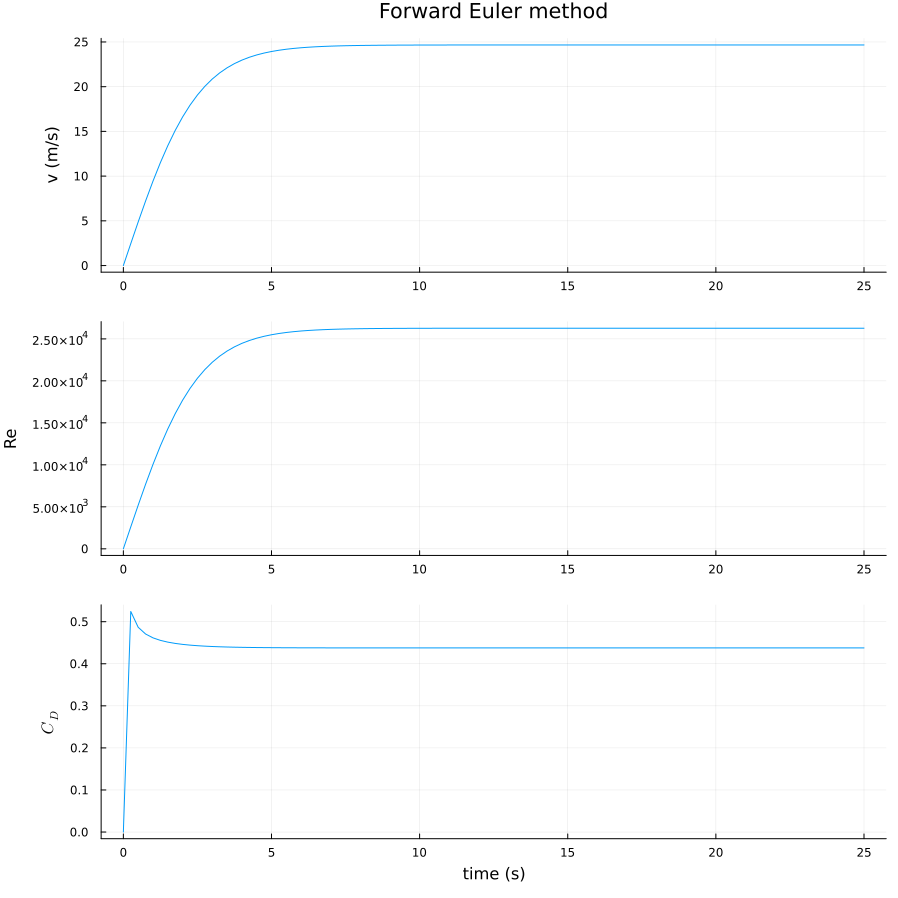

In [56]:
# Time discretization
Tmax = 25.0
N = 100
dt = Tmax / N
display(dt)

# Preallocate solution array 
v = zeros(Float64, N+1)
v[1] = u0

# Forward Euler loop
for n in 2:(N+1)
    f = drop_rhs(v[n-1], p)
    v[n] = v[n-1] + dt * f
end

# Time vector for plotting
t = range(0.0, stop=Tmax, length=N+1)

# Compute Re and CD arrays (broadcasted)
Re = rhog .* v .* (2a) ./ mu
# Avoid division-by-zero in elementwise CD calculation:
CD = similar(Re)
for i in eachindex(Re)
    if abs(Re[i]) > 0.0
        CD[i] = 24 / Re[i] + 6 / (1 + sqrt(Re[i])) + 0.4
    else
        CD[i] = 0.0
    end
end

# Plot results
plt1 = plot(t, v, xlabel="", ylabel="v (m/s)", title="Forward Euler method",label=false) #marker=:circle,markersize=3, )
plt2 = plot(t, Re, ylabel="Re",label=false) # ,marker=:circle,markersize=3)
plt3 = plot(t, CD, xlabel="time (s)", ylabel=L"C_D",label=false)# ,marker=:circle,markersize=3)

plot(plt1, plt2, plt3, layout = (3,1), size=(900,900))

Now let's try the midpoint method

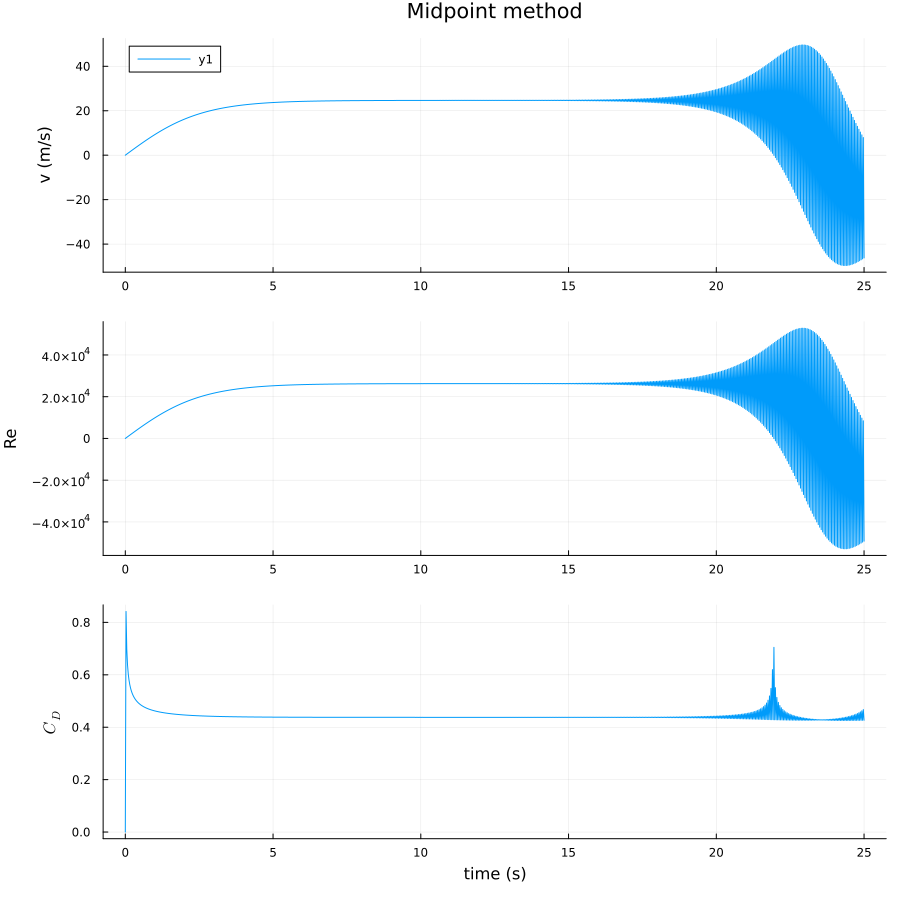

In [36]:
# Time discretization
u0 = 0.0
Tmax = 25.0
N = 1000
dt = Tmax / N

# Preallocate solution array
v = zeros(Float64, N+1)
v[1] = u0

# First step: forward Euler to get v[2]
v[2] = v[1] + dt * drop_rhs(v[1], p)

# Midpoint iterations: for n = 3 .. N+1
for n in 3:(N+1)
    v[n] = v[n-2] + 2.0 * dt * drop_rhs(v[n-1], p)
end

# Time vector for plotting
t = range(0.0, stop=Tmax, length=N+1)

# Compute Re and CD arrays (broadcasted)
Re = rhog .* v .* (2a) ./ mu
# Avoid division-by-zero in elementwise CD calculation:
CD = similar(Re)
for i in eachindex(Re)
    if abs(Re[i]) > 0.0
        CD[i] = 24 / Re[i] + 6 / (1 + sqrt(abs(Re[i]))) + 0.4
    else
        CD[i] = 0.0
    end
end

# Plot results
plt1 = plot(t, v, xlabel="", ylabel="v (m/s)", title="Midpoint method",label=false) # marker=:circle,markersize=3, )
plt2 = plot(t, Re, ylabel="Re",label=false) # ,marker=:circle,markersize=3)
plt3 = plot(t, CD, xlabel="time (s)", ylabel=L"C_D",label=false)# ,marker=:circle,markersize=3)

plot(plt1, plt2, plt3, layout = (3,1), size=(900,900))

For fun, what about an **arbitrary** finite difference approximation?

In [11]:
function stencil(x::AbstractVector{<:Real}, x₀::Real, m::Integer)
    ℓ = 0:length(x)-1
    m in ℓ || throw(ArgumentError("order 
ℓ"))
    A = @. (x' - x₀)^ℓ / factorial(ℓ)
    return A \ (ℓ .== m) # vector of weights w
end

stencil (generic function with 1 method)

In [42]:
stencil([-2, -1, 0, 1], 0//1, 1)

4-element Vector{Rational{Int64}}:
 1//6
 -1
 1//2
 1//3

Try this third-order approximation as a multi-step integration scheme and see what happens:

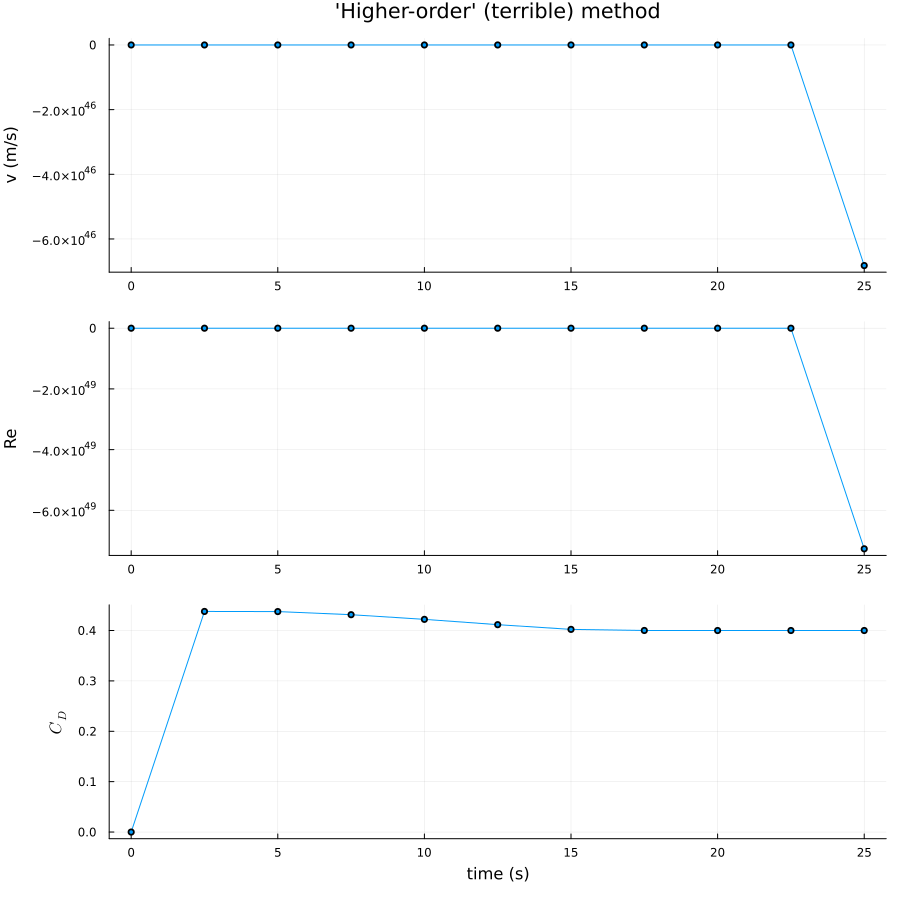

In [70]:
# Time discretization
u0 = 0.0
Tmax = 25.0
N = 10
dt = Tmax / N

# Preallocate solution array
v = zeros(Float64, N+1)
v[1] = u0

# First two steps: forward Euler to get v[2] and v[3]
v[2] = v[1] + dt * drop_rhs(v[1], p)
v[3] = v[2] + dt * drop_rhs(v[2], p)


# "New-scheme" iterations: for n = 4 .. N+1
for n in 4:(N+1)
    v[n] = 3.0 * dt * drop_rhs(v[n-1], p) - 1.5 * v[n-1] + 3.0 * v[n-2] - 0.5 * v[n-3]; 
end

# Time vector for plotting
t = range(0.0, stop=Tmax, length=N+1)

# Compute Re and CD arrays (broadcasted)
Re = rhog .* v .* (2a) ./ mu
# Avoid division-by-zero in elementwise CD calculation:
CD = similar(Re)
for i in eachindex(Re)
    if abs(Re[i]) > 0.0
        CD[i] = 24 / Re[i] + 6 / (1 + sqrt(abs(Re[i]))) + 0.4
    else
        CD[i] = 0.0
    end
end

# Plot results
plt1 = plot(t, v, xlabel="", ylabel="v (m/s)", title="'Higher-order' (terrible) method",label=false, marker=:circle,markersize=3, )
plt2 = plot(t, Re, ylabel="Re",label=false,marker=:circle,markersize=3)
plt3 = plot(t, CD, xlabel="time (s)", ylabel=L"C_D",label=false,marker=:circle,markersize=3)

plot(plt1, plt2, plt3, layout = (3,1), size=(900,900))

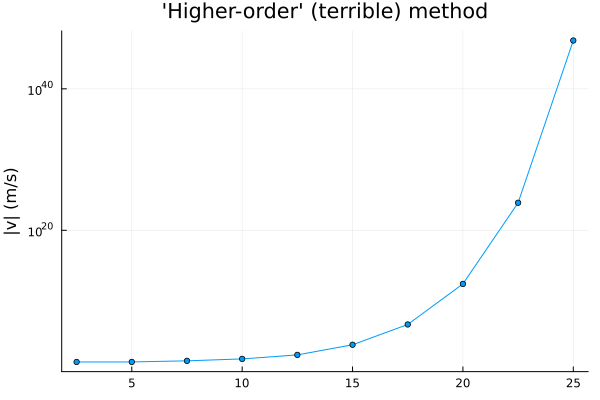

In [69]:
# Plot in a nicer way
plt1 = plot(t[2:end], abs.(v[2:end]), xlabel="", ylabel="|v| (m/s)", title="'Higher-order' (terrible) method",label=false,
    marker=:circle,markersize=3,yscale=:log10)
# plt2 = plot(t, abs.(Re), ylabel="Re",label=false,marker=:circle,markersize=3,yscale=:log10)
# plt3 = plot(t, CD, xlabel="time (s)", ylabel=L"C_D",label=false,marker=:circle,markersize=3)

plot(plt1)

In [67]:
v

11-element Vector{Float64}:
      0.0
     24.5
     24.81833670742369
     36.662036855338116
    -78.82721937860344
   -448.22391981897096
 -23355.45336593015
     -6.471187382059349e7
     -4.9705223037300875e14
     -2.9325013065038765e28
     -1.0207293180121762e56